In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import networkx as nx
import simulator_fn
from simulator_fn import *
# from fitness_fn_simple import get_metrics
# from simple_optimization import *

In [36]:
exec_idx = "NM2"

In [37]:
best_solution = np.load(f"./solutions/best_solution-{exec_idx}.npy")
best_solution

array([[[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0., -18.],
        [  0.,   0.,   0.,   0.,   0.,  13.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,  13.,  13.,   8.]],

       [[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.],
        [  0.,   0.,   0.,   0.,   0.,   3.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   2.,   5.,   3.]]])

{(0, 2): -18.0, (1, 0): 13.0, (2, 0): 13.0, (2, 1): 13.0, (2, 2): 8.0}
{(0, 2): 3.0, (1, 0): 3.0, (2, 0): 2.0, (2, 1): 5.0, (2, 2): 3.0}


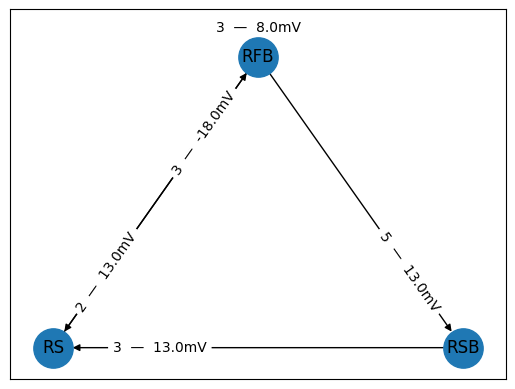

In [38]:
graph1 = nx.DiGraph(best_solution[0, -3:, -3:])
graph2 = nx.DiGraph(best_solution[1, -3:, -3:])

pos = nx.planar_layout(graph1)
nx.draw_networkx_nodes(graph1, pos, node_size=800)
nx.draw_networkx_edges(graph1, pos, node_size=800, arrows=True)
weight_labels_aux1 = nx.get_edge_attributes(graph1, 'weight')
weight_labels_aux2 = nx.get_edge_attributes(graph2, 'weight')
print(weight_labels_aux1)
print(weight_labels_aux2)
weight_labels = {}
for key, v in weight_labels_aux1.items():
    weight_labels[key] = f"{int(weight_labels_aux2[key])}  —  {weight_labels_aux1[key]}mV"
nx.draw_networkx_edge_labels(graph1, pos, edge_labels=weight_labels, label_pos=0.75)
nx.draw_networkx_labels(graph1, pos, labels={0: "RS", 1: "RSB", 2: "RFB"}, )
plt.show()

In [39]:
np.load(f"./solutions/population-{exec_idx}.npy")

array([[  0.,   0., -18.,  13.,   0.,   0.,  13.,  13.,   8.,   3.,   2.,
          3.,   3.,   3.,   1.,   2.,   5.,   3.],
       [-13.,   0., -13.,  13.,   0.,   0.,   8.,  13.,   8.,   3.,   3.,
          3.,   3.,   3.,   1.,   3.,   5.,   2.],
       [  0., -18., -13.,  13.,   0.,   0.,  13.,  13.,   8.,   3.,   3.,
          4.,   3.,   2.,   3.,   3.,   3.,   3.],
       [  0.,   0., -13.,  13.,   0.,  13.,  13.,  13.,   8.,   2.,   4.,
          3.,   5.,   1.,   1.,   3.,   2.,   2.],
       [-18.,   0.,  -8.,   0.,  13.,  13.,  13.,  13.,   0.,   2.,   3.,
          2.,   1.,   3.,   3.,   3.,   5.,   2.],
       [-18.,   0., -13.,   0.,  13.,   8.,  13.,  13.,   8.,   2.,   3.,
          2.,   1.,   3.,   3.,   3.,   5.,   2.],
       [-13.,   0., -13.,   0.,  13.,   8.,  13.,  13.,   8.,   2.,   3.,
          2.,   1.,   2.,   1.,   3.,   5.,   2.],
       [-13.,   0.,  -8.,   0.,  13.,   8.,  13.,  13.,  13.,   2.,   3.,
          2.,   1.,   3.,   1.,   3.,   5.,   2.],


time simulator: 5.046749591827393s
time metrics: 0.005471467971801758s
{'Freq': 0.19449576971700866, 'Freq_naive': 0.040234972237869156, 'N_dead_neurons': 0, 'CV': 0.5981387078506294}


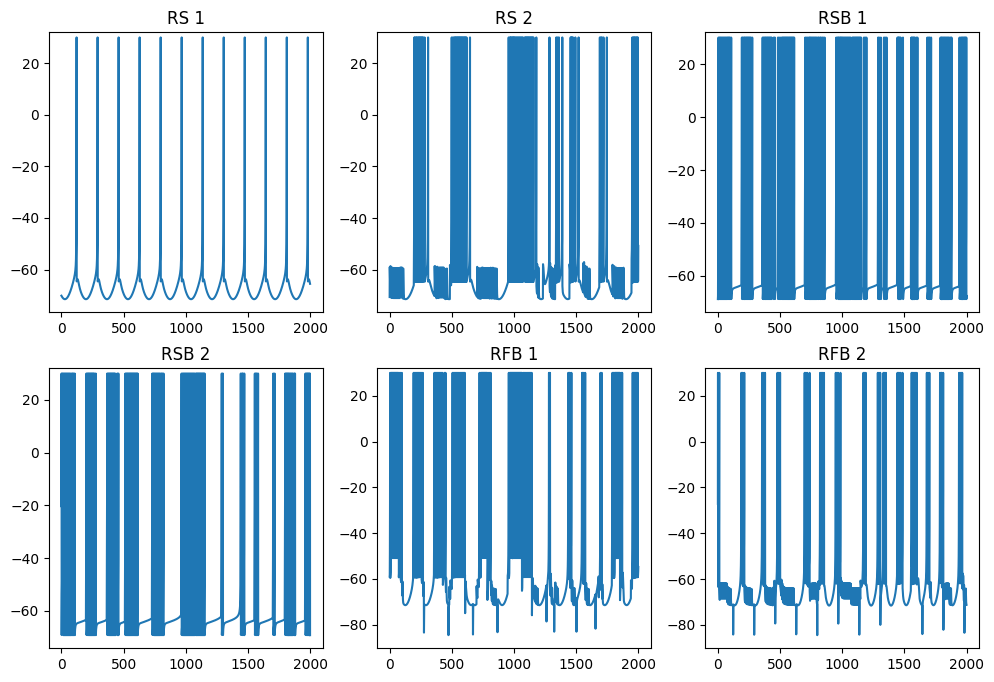

In [40]:
simulation_time = 100
neuron_amounts = (0, 0, 0, 0, 0, 12, 6, 2)
adj_matrix = best_solution[0]
conn_matrix = best_solution[1]

t0 = time.time()
sim, volt = run_simulator(adj_matrix, conn_matrix, simulation_time=simulation_time, neuron_amounts=neuron_amounts, record_volt=True)
t1 = time.time()
print(f"time simulator: {t1 - t0}s")

t0 = time.time()
metrics = simulator_fn.get_metrics(sim, simulation_time=simulation_time, burst_thesh=0.02)
t1 = time.time()
print(f"time metrics: {t1 - t0}s")

print(metrics)

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
ax_flat = ax.flatten()

window = slice(2000,4000)
ax[0, 0].plot(volt[0, window])
ax[0, 1].plot(volt[1, window])
ax[0, 2].plot(volt[14, window])
ax[1, 0].plot(volt[15, window])
ax[1, 1].plot(volt[18, window])
ax[1, 2].plot(volt[19, window])

ax[0, 0].set(title=f"RS 1", ylim=(None, 32))
ax[0, 1].set(title=f"RS 2", ylim=(None, 32))
ax[0, 2].set(title=f"RSB 1", ylim=(None, 32))
ax[1, 0].set(title=f"RSB 2", ylim=(None, 32))
ax[1, 1].set(title=f"RFB 1", ylim=(None, 32))
ax[1, 2].set(title=f"RFB 2", ylim=(None, 32))

plt.show()

In [41]:
n_idx = 0

591


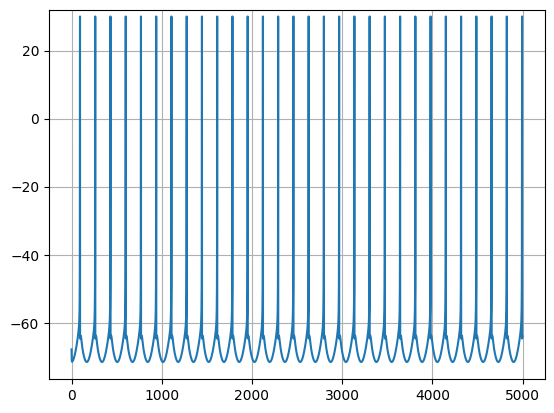

In [42]:
# plt.stem(volt[15, :1000], bottom=-80)
print(np.count_nonzero(np.diff(sim[n_idx]) > 0.02))
plt.plot(volt[n_idx, :5000])
plt.ylim((None, 32))
plt.grid()
plt.show()
n_idx = (n_idx+1) % len(volt)

1 0.0029999999999992255 0.9210000000000065


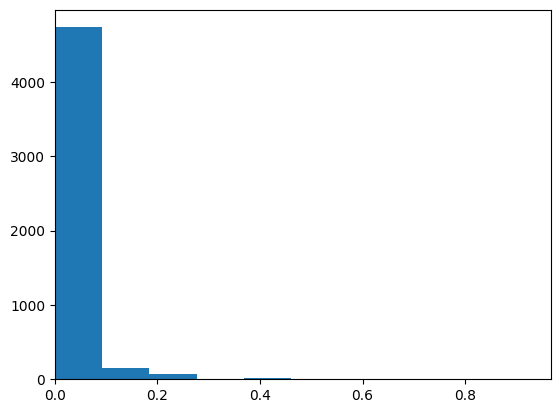

In [43]:
diff_times = np.diff(sim[n_idx])
while len(diff_times) < 1:
    n_idx = (n_idx+1) % len(volt)
    diff_times = np.diff(sim[n_idx])

print(n_idx, min(diff_times), max(diff_times))
plt.hist(np.concatenate((diff_times, [0])))
plt.xlim((0, None))

n_idx = (n_idx+1) % len(volt)

In [44]:
neuron_type_names = ["ISe", "ISi", "ISB", "IFB", "A", "RS", "RSB", "RFB"]
neuron_names = []
for type_name, type_amount in zip(neuron_type_names, neuron_amounts):
    neuron_names += [f"{i+1:2d} {type_name:3}" for i in range(type_amount)]
    
neuron_names

[' 1 RS ',
 ' 2 RS ',
 ' 3 RS ',
 ' 4 RS ',
 ' 5 RS ',
 ' 6 RS ',
 ' 7 RS ',
 ' 8 RS ',
 ' 9 RS ',
 '10 RS ',
 '11 RS ',
 '12 RS ',
 ' 1 RSB',
 ' 2 RSB',
 ' 3 RSB',
 ' 4 RSB',
 ' 5 RSB',
 ' 6 RSB',
 ' 1 RFB',
 ' 2 RFB']

In [45]:
plot_window = slice(10.0, 13.0)

/tmp/ipykernel_193512/584479695.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(


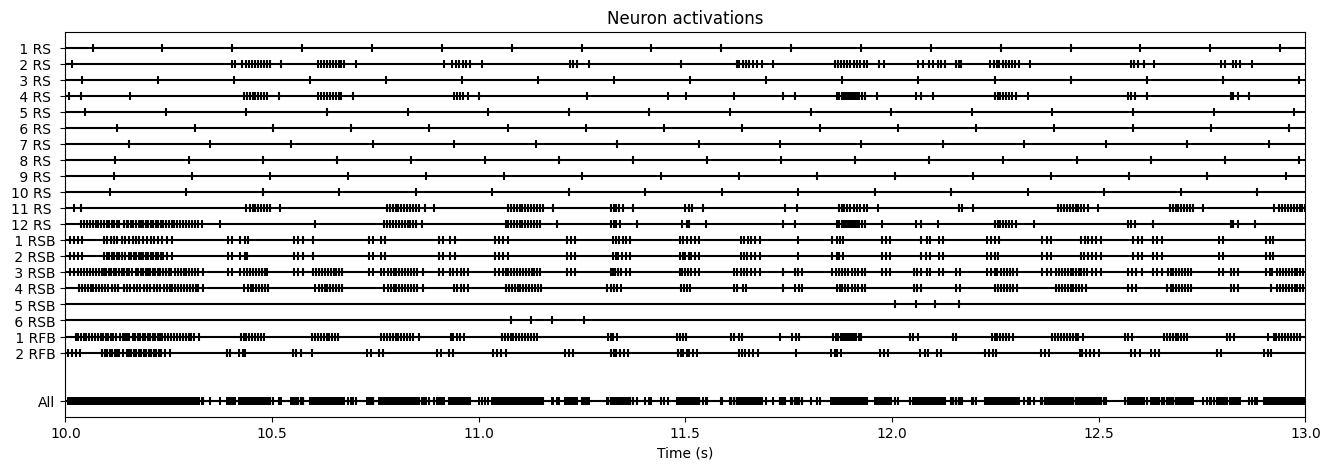

In [46]:
fig, ax = plt.subplots(1,1, figsize=(16,5))

voffset = 3
yticks = len(sim) - np.arange(len(sim)) + voffset
yticks = list(yticks) + [1]

ax.axhline(1, color='k')
for idx, sim_n in enumerate(sim):
    h = len(sim) - idx + voffset
    sim_n_arr = np.asarray(sim_n)
    sim_n_arr = sim_n_arr[(sim_n_arr > plot_window.start) | (sim_n_arr < plot_window.stop)]
    ax.axhline(h, color='k')
    ax.scatter(sim_n_arr, np.full_like(sim_n_arr, h), marker="|", color="k")
    ax.scatter(sim_n_arr, np.full_like(sim_n_arr, 1), marker="|", color="k")
    
ax.set(
    xlim=(plot_window.start, plot_window.stop),
    xlabel="Time (s)",
    ylim=(0, len(sim)+voffset+1),
    title="Neuron activations",
    yticklabels=neuron_names + ["All"],
    yticks=yticks
)
plt.show()

# Old frequency calculation

30
0.3


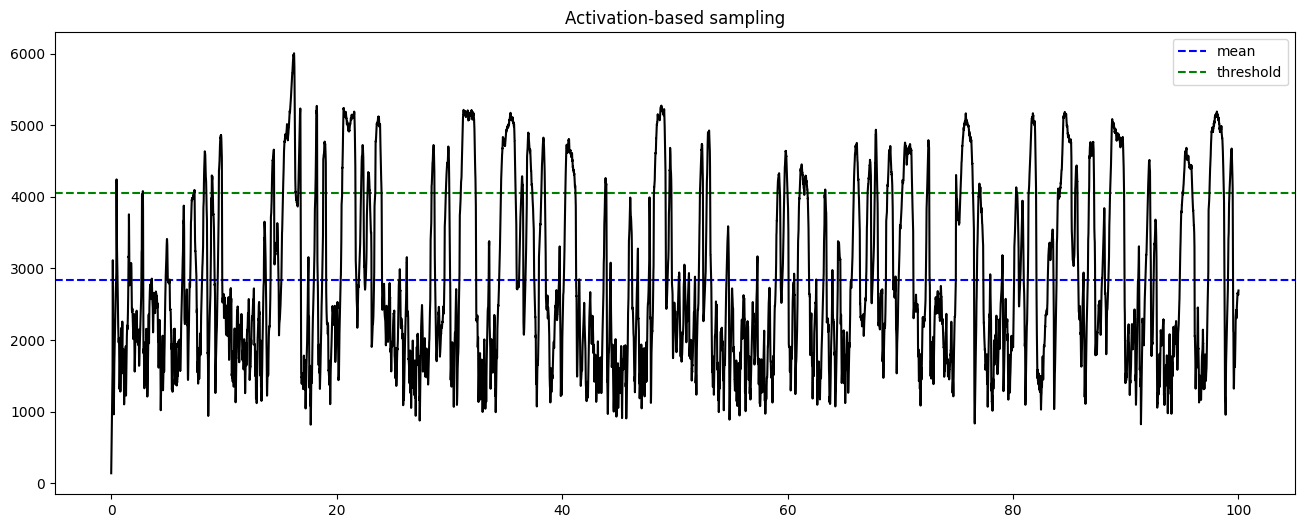

In [47]:
freq_ts = calculate_frequency_irregular(sim, simulation_time=simulation_time, sampling=1e-3, bin_size=0.2)
freq_ts = np.convolve(freq_ts, np.ones(7), 'valid')

match exec_idx:
    case "NM1":
        d = 1.5
    case "NM2":
        d = 1
    case _:
        d = 2.5

print(count_peaks(freq_ts, d=d))
print(count_peaks(freq_ts, d=d)/simulation_time)

fig, ax = plt.subplots(1,1, figsize=(16,6))
plt.plot(np.linspace(0, simulation_time, len(freq_ts)), freq_ts, color='k')
plt.axhline(freq_ts.mean(), c="blue", ls="--", label="mean", zorder=-10)
plt.axhline(freq_ts.mean() + d*freq_ts.std(), c="green", ls="--", label="threshold", zorder=-10)
plt.title("Activation-based sampling")
plt.legend()
plt.show()

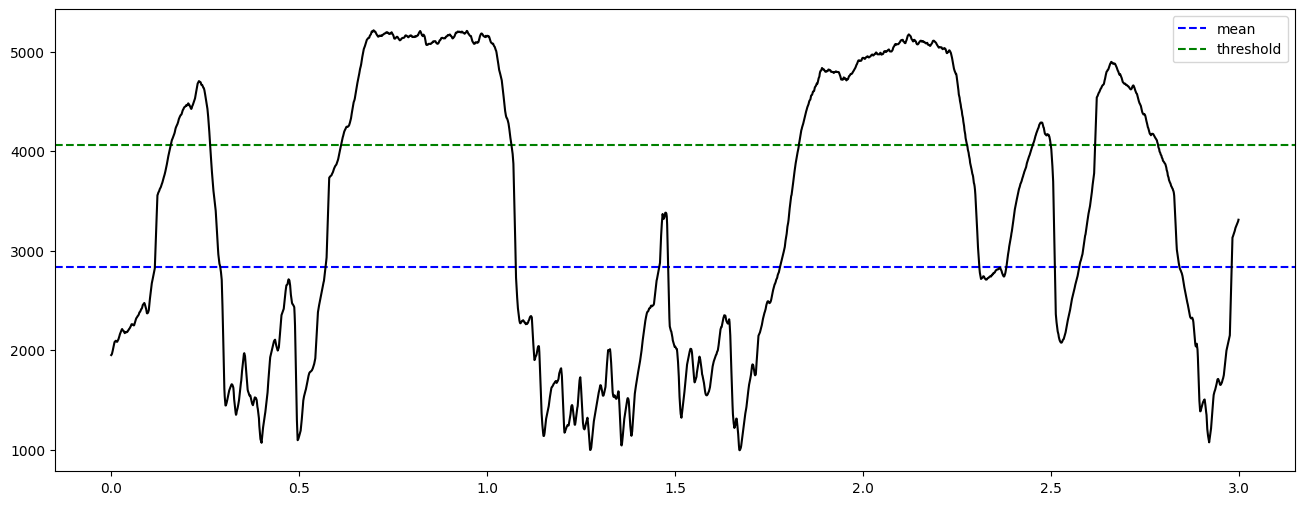

In [48]:
freq_ts_plot = freq_ts[int(plot_window.start*1000):int(plot_window.stop*1000)]

fig, ax = plt.subplots(1,1, figsize=(16,6))
plt.plot(np.arange(freq_ts_plot.shape[0])/1000, freq_ts_plot, color='k')
plt.axhline(freq_ts.mean(), c="blue", ls="--", label="mean", zorder=-10)
plt.axhline(freq_ts.mean() + d*freq_ts.std(), c="green", ls="--", label="threshold", zorder=-10)
plt.legend()
plt.show()

# New frequency calculation

56
0.56


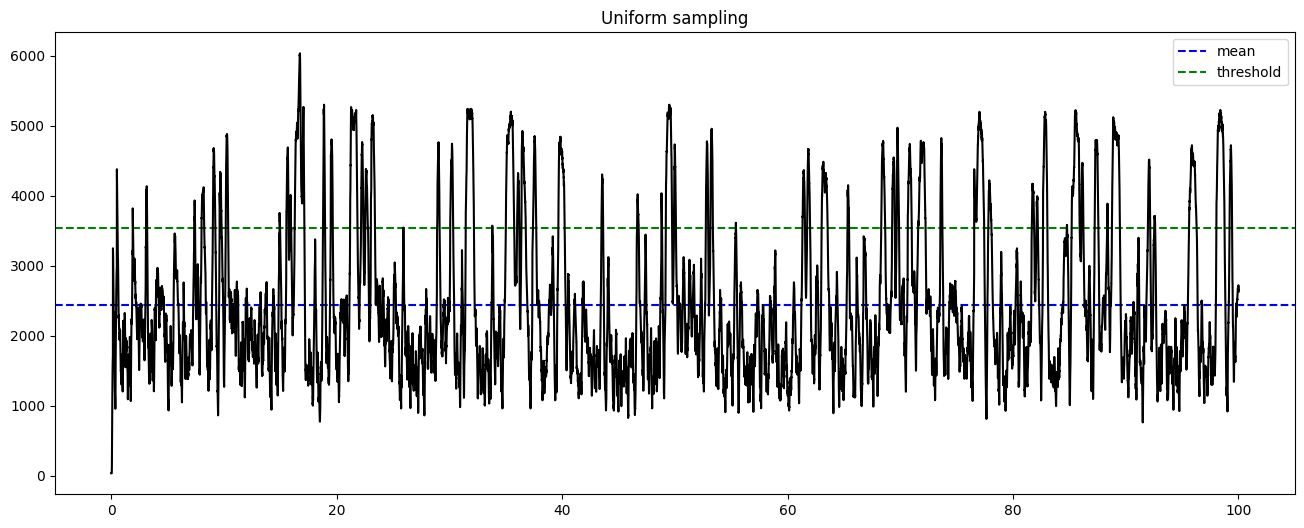

In [49]:
freq_ts = calculate_frequency(sim, simulation_time=simulation_time, sampling=1e-3, bin_size=0.2)
freq_ts = np.convolve(freq_ts, np.ones(7), 'valid')

match exec_idx:
    case "NM1":
        d = 1.5
    case "NM2":
        d = 1
    case _:
        d = 2.5

print(count_peaks(freq_ts, d=d))
print(count_peaks(freq_ts, d=d)/simulation_time)

fig, ax = plt.subplots(1,1, figsize=(16,6))
plt.plot(np.linspace(0, simulation_time, len(freq_ts)), freq_ts, color='k')
plt.axhline(freq_ts.mean(), c="blue", ls="--", label="mean", zorder=-10)
plt.axhline(freq_ts.mean() + d*freq_ts.std(), c="green", ls="--", label="threshold", zorder=-10)
plt.title("Uniform sampling")
plt.legend()
plt.show()


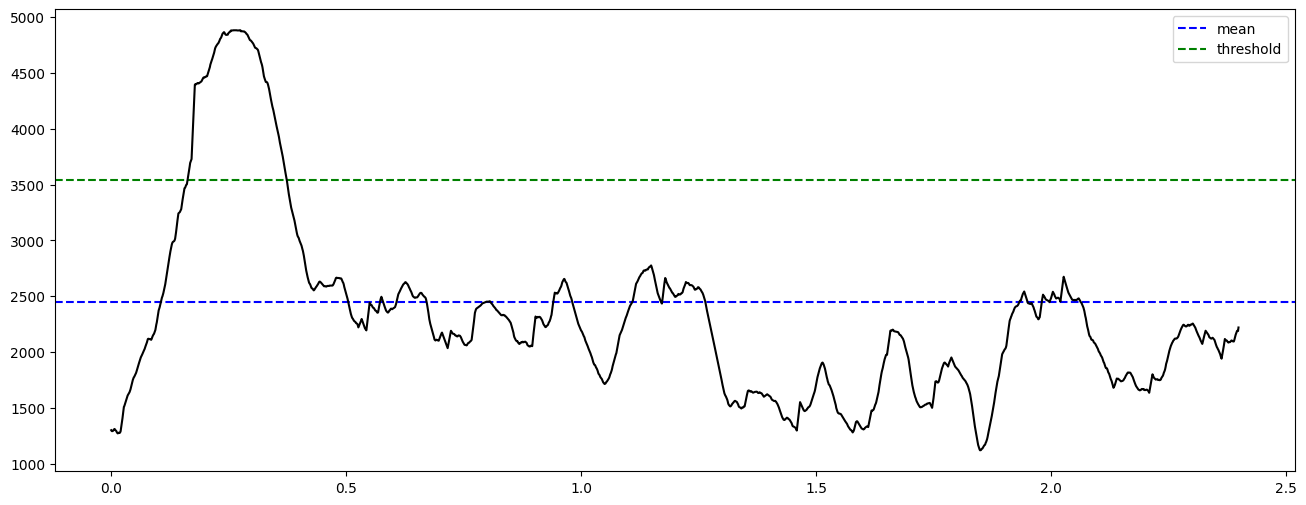

In [50]:
freq_ts_plot = freq_ts[int(plot_window.start*1000):int(plot_window.stop*1000)-600]

fig, ax = plt.subplots(1,1, figsize=(16,6))
plt.plot(np.arange(freq_ts_plot.shape[0])/1000, freq_ts_plot, color='k')
plt.axhline(freq_ts.mean(), c="blue", ls="--", label="mean", zorder=-10)
plt.axhline(freq_ts.mean() + d*freq_ts.std(), c="green", ls="--", label="threshold", zorder=-10)
plt.legend()
plt.show()